In [1]:
!pip install prophet

In [2]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import pickle

In [3]:
#Load dataset\
df = pd.read_csv("/content/feature_engineered_data.csv")

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce",
    format="mixed"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayOfWeek,Hour,Quarter,IsWeekend,BasketSize,OrderValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7.0,4.0,0.0,166.0,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7.0,4.0,0.0,166.0,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7.0,4.0,0.0,166.0,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday,7.0,4.0,0.0,166.0,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday,7.0,4.0,0.0,166.0,505.3


In [4]:
#prepare daiy sale data
forecast_df = df.groupby("InvoiceDate")["Revenue"].sum().reset_index()

forecast_df.columns = ["ds", "y"]

forecast_df.head()

,ds,y
0,2009-12-01 07:45:00,505.30
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,630.33
3,2009-12-01 09:08:00,310.75
4,2009-12-01 09:24:00,2286.24


In [5]:
#Train Prohet model
model = Prophet()

model.fit(forecast_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [6]:
#30 Days forecast
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01 07:45:00,512.267334,-1164.188087,2512.830766,512.267334,512.267334,160.220134,160.220134,160.220134,114.667946,114.667946,114.667946,45.552189,45.552189,45.552189,0.0,0.0,0.0,672.487468
1,2009-12-01 07:46:00,512.268158,-1194.895785,2362.952314,512.268158,512.268158,156.839189,156.839189,156.839189,111.228336,111.228336,111.228336,45.610853,45.610853,45.610853,0.0,0.0,0.0,669.107346
2,2009-12-01 09:06:00,512.334029,-1361.022068,2317.163847,512.334029,512.334029,-77.583049,-77.583049,-77.583049,-127.502515,-127.502515,-127.502515,49.919465,49.919465,49.919465,0.0,0.0,0.0,434.750980
3,2009-12-01 09:08:00,512.335676,-1522.676753,2177.483514,512.335676,512.335676,-81.123552,-81.123552,-81.123552,-131.140785,-131.140785,-131.140785,50.017233,50.017233,50.017233,0.0,0.0,0.0,431.212124
4,2009-12-01 09:24:00,512.348850,-1390.933598,2294.895557,512.348850,512.348850,-103.626103,-103.626103,-103.626103,-154.407614,-154.407614,-154.407614,50.781512,50.781512,50.781512,0.0,0.0,0.0,408.722748


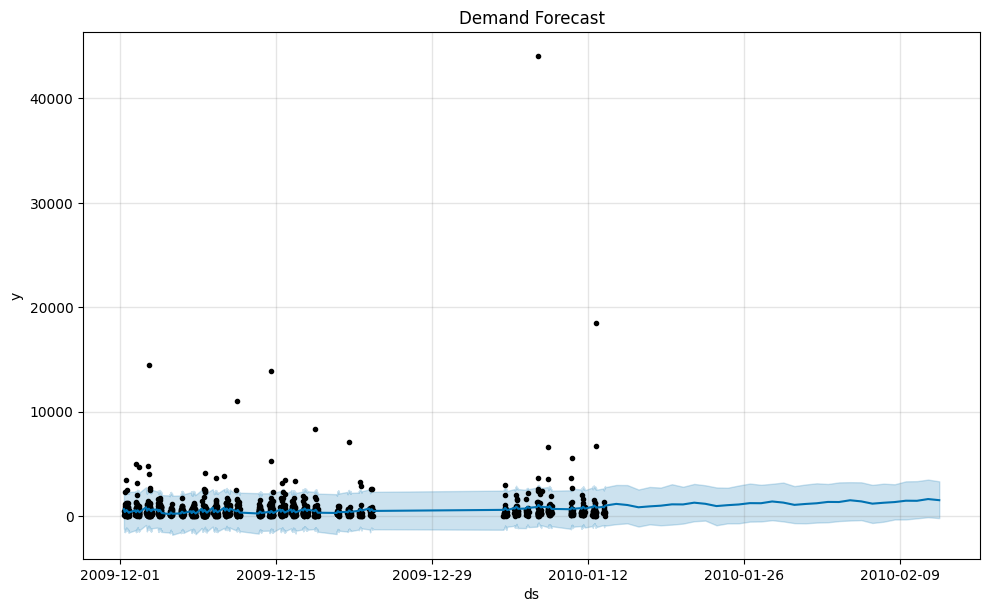

In [7]:
fig = model.plot(forecast)
plt.title("Demand Forecast")
plt.show()

In [8]:
#Forecast CSv save
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(
    "forecast_predictions.csv",
    index=False
)

print("✅ Forecast Prediction CSV Saved")

✅ Forecast Prediction CSV Saved


In [9]:
#Prophate Model Save
import pickle

with open("forecast_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Forecast Model Saved")

✅ Forecast Model Saved


In [10]:
#Performance matrix save
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = forecast_df["y"]
predicted = forecast["yhat"][:len(actual)]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 444.8994302423042
RMSE : 1418.8702468569982
